In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Ingection

In [3]:
#ingesting train dataset for EDA

df = pd.read_csv("loan-train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Checking data shape before joining train and test dataset together
df.shape

(614, 13)

## Preliminary Data Analysis

In [5]:
# Checking the shape of the new joined dataset
df.shape

(614, 13)

In [6]:
# chcking the tail of the new dataset to see if the index number is aligned
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [7]:
# checking the column names of the dataset

df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [8]:
# checking information about each column in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Data Cleaning

In [9]:
# checking the number missing data per columns 

df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Handling columns with missing data

In [10]:
# 1- Handling Gender missing data
# knowing the most present gender
gender_mode= df["Gender"].mode()[0]
print("The highest borrowing gender is", gender_mode)

# fill missing data with mode 
df["Gender"] = df["Gender"].fillna(gender_mode)
print(f"\n {df["Gender"].head(5)}")
# check id there is still missing data 
print("\nThe number of missing data is", df["Gender"].isna().sum())

The highest borrowing gender is Male

 0    Male
1    Male
2    Male
3    Male
4    Male
Name: Gender, dtype: object

The number of missing data is 0


In [11]:
# 2- Handling Married missing data 

married_mode = df["Married"].mode()[0]
df["Married"] = df["Married"].fillna(married_mode)

# check id there is still missing data 
print("\nThe number of missing data for married is", df["Married"].isna().sum())


The number of missing data for married is 0


In [12]:
# 3- Handling Dependency Dataset

Dependents_mode = df["Dependents"].mode()[0]
df["Dependents"] = df["Dependents"].fillna(Dependents_mode)

# check id there is still missing data 
print("\nThe number of missing data for Dependents is", df["Dependents"].isna().sum())


The number of missing data for Dependents is 0


In [13]:
# checking the number missing data per columns 

df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
# 4- Handling Self_Employed Dataset

Self_Employed_mode = df["Self_Employed"].mode()[0]
df["Self_Employed"] = df["Self_Employed"].fillna(Self_Employed_mode)

# check id there is still missing data 
print("\nThe number of missing data for Self_Employed is", df["Self_Employed"].isna().sum())


The number of missing data for Self_Employed is 0


In [15]:
# 5- Handling Self_Employed Dataset 
# since loan amount is an important feature of the dataset and cannot be filled will with mean because of the present of outliers. Let's drop the rows

df.drop(df[df["LoanAmount"].isna()].index, inplace=True)

df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
# 6- Handling Loan Amount Term

Loan_Amount_Term_mode = df["Loan_Amount_Term"].mode()[0]
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(Loan_Amount_Term_mode)

# check id there is still missing data 
print("\nThe number of missing data for Loan_Amount_Term is", df["Loan_Amount_Term"].isna().sum())


The number of missing data for Loan_Amount_Term is 0


In [17]:
# 7-  HAndling Credit_History
# fill column with 0

df["Credit_History"].fillna(0, inplace=True)
df["Credit_History"].isna().sum()



np.int64(0)

In [18]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [19]:
df.head(8)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y


In [20]:
df["Dependents"].unique()

array(['1', '0', '2', '3+'], dtype=object)

In [21]:
df["Dependents"]=df["Dependents"].replace("3+", "4")
df["Dependents"].head(10)

1     1
2     0
3     0
4     0
5     2
6     0
7     4
8     2
9     1
10    2
Name: Dependents, dtype: object

In [22]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [23]:
# df[["Dependents", "ApplicantIncome"]].astype("float16")
df["Dependents"].astype("int64")
df["ApplicantIncome"].astype("float64")

1      4583.0
2      3000.0
3      2583.0
4      6000.0
5      5417.0
        ...  
609    2900.0
610    4106.0
611    8072.0
612    7583.0
613    4583.0
Name: ApplicantIncome, Length: 592, dtype: float64

In [24]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

# Exploratory Data Analysis

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,592.0,5404.304054,6164.073003,150.0,2887.25,3806.0,5754.5,81000.0
CoapplicantIncome,592.0,1642.633311,2967.717486,0.0,0.00,1221.0,2312.0,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.00,128.0,168.0,700.0
Loan_Amount_Term,592.0,342.567568,64.719325,12.0,360.00,360.0,360.0,480.0
Credit_History,592.0,0.773649,0.418823,0.0,1.00,1.0,1.0,1.0


Observations on Numeric features


|Feature                |Distribution     | Outliers        |Spread
|--------------------|-----------------------|-------------------|----------------|
|Applicants Income| widely distributed| Heavily present| Widely spread|
|Coapplicant Incomme| roughly normal | heavily present especially from 25% -50% and 75%-max(100%) | widely spread
|Loan Amount | roughly normal | Heavily present |roughly spread |
|Loan Amount Term | roughly normal |Present between 75% - max(100%) |
|Credit History|normal | Absent apart from borrowers in the minimum range |moderately spread| 

In [26]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [27]:
# Let set loan ID as index 
df.set_index("Loan_ID", inplace=True)

In [28]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [29]:
# Checking data for Gender

pd.DataFrame(df["Gender"].value_counts())

# Report: The highest borrowers are male 


,count
Gender,
Male,483
Female,109


In [30]:
pd.DataFrame(df["Married"].value_counts())

# Report: Maried people borrow more loans than singles

,count
Married,
Yes,386
No,206


In [31]:
pd.DataFrame(df["Dependents"].value_counts())

# Report: People with no dependent tends to borrow more than those with dependents

,count
Dependents,
0,347
1,98
2,98
4,49


In [32]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [33]:
pd.DataFrame(df["Education"].value_counts())

# Report: People with education obtain loan with people with no education

,count
Education,
Graduate,465
Not Graduate,127


In [34]:
pd.DataFrame(df["Self_Employed"].value_counts())

# Report: majority of people that obtain loan are salary earners

,count
Self_Employed,
No,513
Yes,79


In [35]:
pd.DataFrame(df["Credit_History"].value_counts())

# Report: People who pay their loans are higher than those that don't 

,count
Credit_History,
1.0,458
0.0,134


In [36]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [37]:
pd.DataFrame(df["Property_Area"].value_counts())

# Report: people living in the semiurban area borrows more loan than in urban and rural areas


,count
Property_Area,
Semiurban,228
Urban,191
Rural,173


In [38]:
pd.DataFrame(df["Loan_Status"].value_counts())

,count
Loan_Status,
Y,411
N,181


# Univariate Analysis

In [39]:

def univariate_numerical_eda(df, column):
    """
    Performs univariate EDA on a single numerical column.
    Displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.
    """    
    print(f" Feature: {column}")
    print("="*40)
    print(df[column].describe().to_frame())
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=30, color='teal')
    plt.title(f'\n Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[column], color='teal')
    plt.title(f'\n Boxplot of {column}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # Optional note on transformation
    if abs(df[column].skew()) > 1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew()) > 0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")



In [40]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [41]:
# lets pick out the numerical columns and get the descriptions
num_features = df.select_dtypes(include=['float64', 'int64']).columns
num_features

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

 Feature: Dependents
       Dependents
count         592
unique          4
top             0
freq          347

Skewness: 1.454
Kurtosis: 1.189


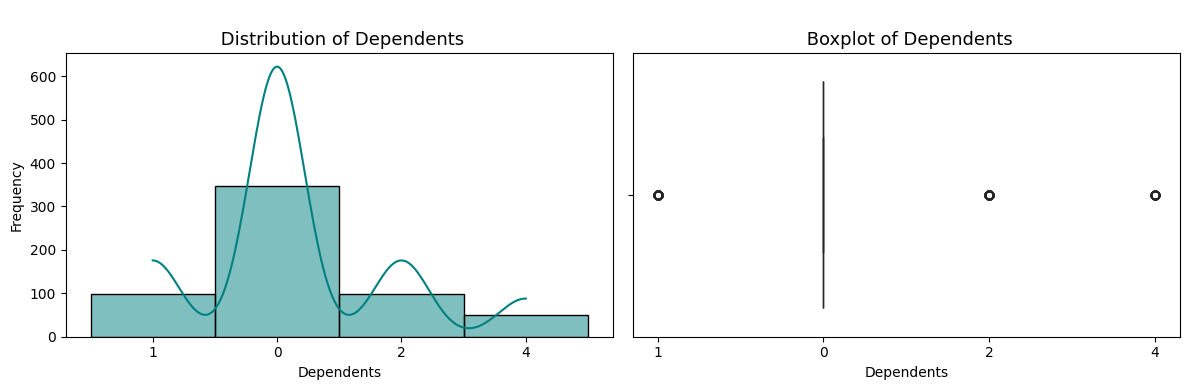


 Dependents is highly skewed. Consider log or Box-Cox transformation.


In [42]:
univariate_numerical_eda(df, "Dependents")

 Feature: ApplicantIncome
       ApplicantIncome
count       592.000000
mean       5404.304054
std        6164.073003
min         150.000000
25%        2887.250000
50%        3806.000000
75%        5754.500000
max       81000.000000

Skewness: 6.575
Kurtosis: 60.531


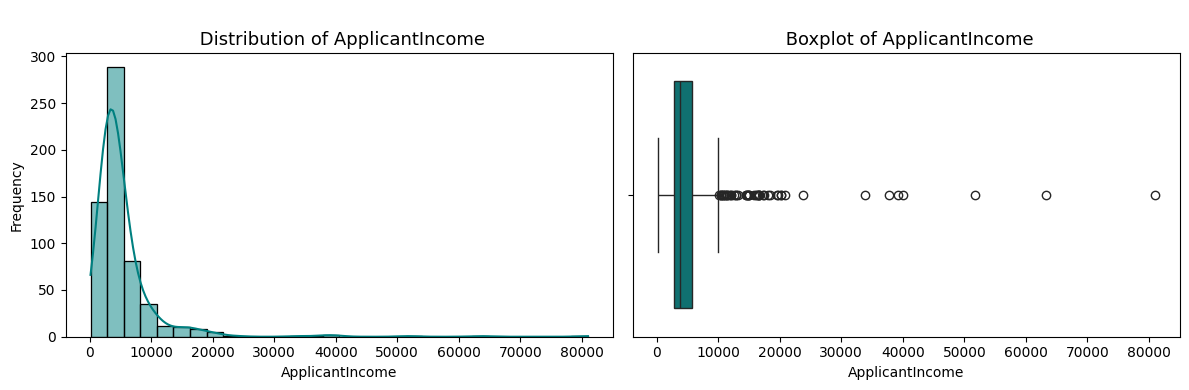


 ApplicantIncome is highly skewed. Consider log or Box-Cox transformation.
 Feature: CoapplicantIncome
       CoapplicantIncome
count         592.000000
mean         1642.633311
std          2967.717486
min             0.000000
25%             0.000000
50%          1221.000000
75%          2312.000000
max         41667.000000

Skewness: 7.430
Kurtosis: 83.049


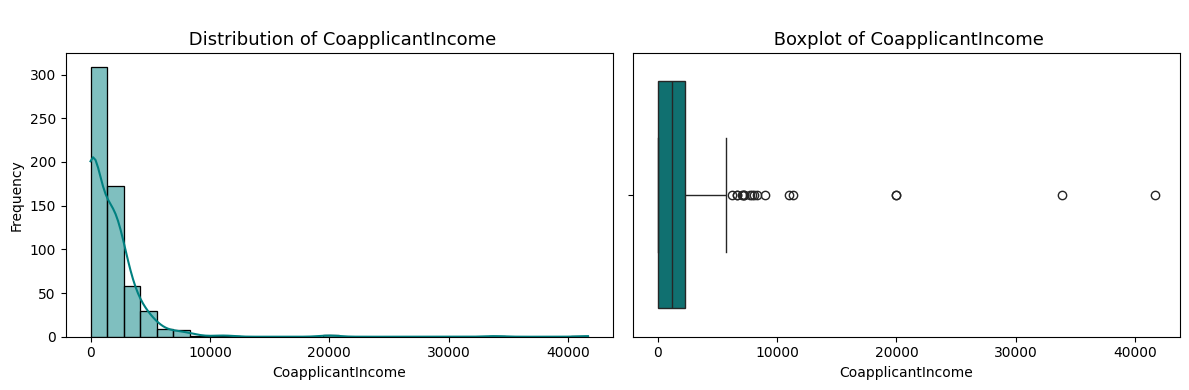


 CoapplicantIncome is highly skewed. Consider log or Box-Cox transformation.
 Feature: LoanAmount
       LoanAmount
count  592.000000
mean   146.412162
std     85.587325
min      9.000000
25%    100.000000
50%    128.000000
75%    168.000000
max    700.000000

Skewness: 2.678
Kurtosis: 10.402


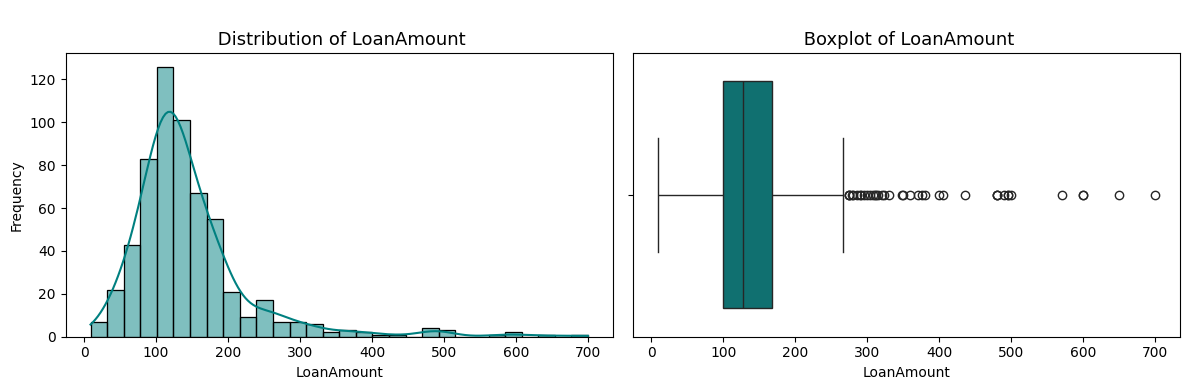


 LoanAmount is highly skewed. Consider log or Box-Cox transformation.
 Feature: Loan_Amount_Term
       Loan_Amount_Term
count        592.000000
mean         342.567568
std           64.719325
min           12.000000
25%          360.000000
50%          360.000000
75%          360.000000
max          480.000000

Skewness: -2.406
Kurtosis: 6.991


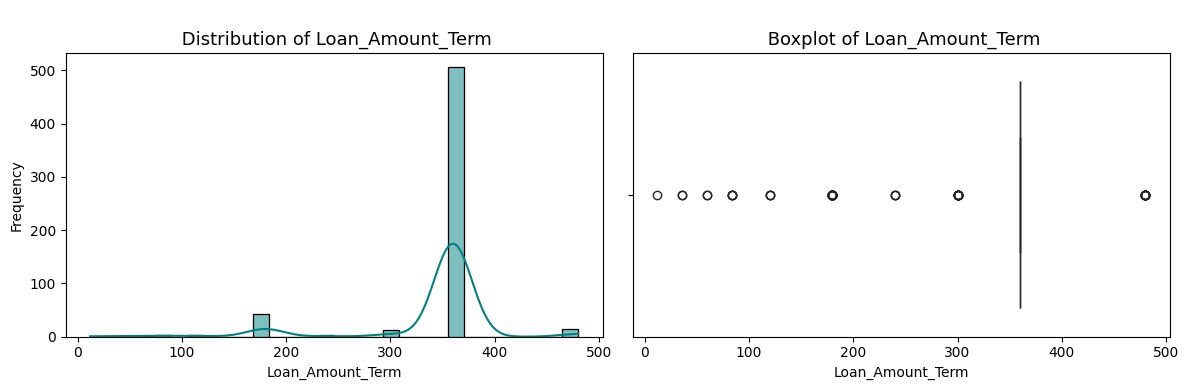


 Loan_Amount_Term is highly skewed. Consider log or Box-Cox transformation.
 Feature: Credit_History
       Credit_History
count      592.000000
mean         0.773649
std          0.418823
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000

Skewness: -1.311
Kurtosis: -0.282


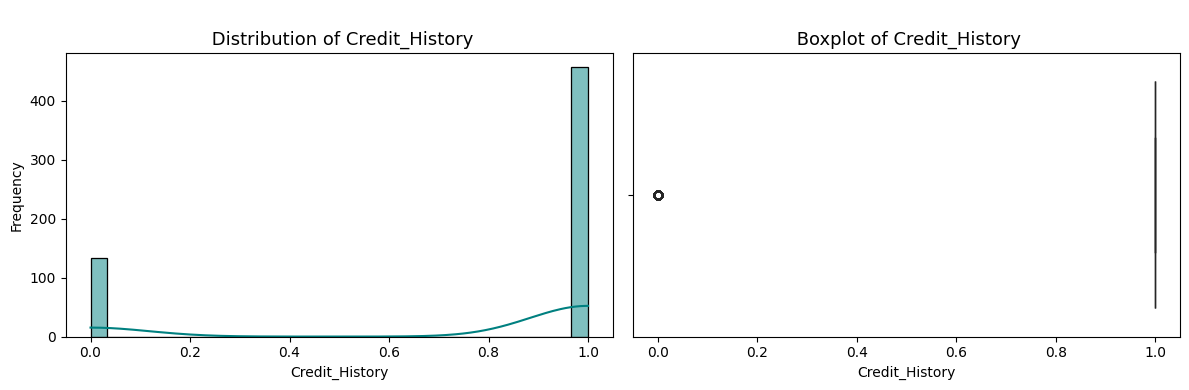


 Credit_History is highly skewed. Consider log or Box-Cox transformation.


In [43]:
for column in num_features:
    univariate_numerical_eda(df, column)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 592 entries, LP001003 to LP002990
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             592 non-null    object 
 1   Married            592 non-null    object 
 2   Dependents         592 non-null    object 
 3   Education          592 non-null    object 
 4   Self_Employed      592 non-null    object 
 5   ApplicantIncome    592 non-null    int64  
 6   CoapplicantIncome  592 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   592 non-null    float64
 9   Credit_History     592 non-null    float64
 10  Property_Area      592 non-null    object 
 11  Loan_Status        592 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 76.3+ KB


In [45]:

categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [46]:
def univariate_categorical_eda(df, column):
    """
    Performs univariate EDA on a categorical or ordinal column.
    Displays frequency table, proportion, and a countplot.
    """
    print(f"Feature: {column}")
    print("="*40)

    # Frequency + proportion
    freq = df[column].value_counts()
    prop = df[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': freq, 'Percentage': prop.round(2)})
    print(summary)
    print()

    # Visualization
    plt.figure(figsize=(8,5))
    ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')
    plt.title(f'Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Count')

    # Annotate each bar with percentage
    total = len(df[column])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, height + 1,
                f'{(height/total)*100:.1f}%', ha='center')

    plt.tight_layout()
    plt.show()


Feature: Gender
        Count  Percentage
Gender                   
Male      483       81.59
Female    109       18.41



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


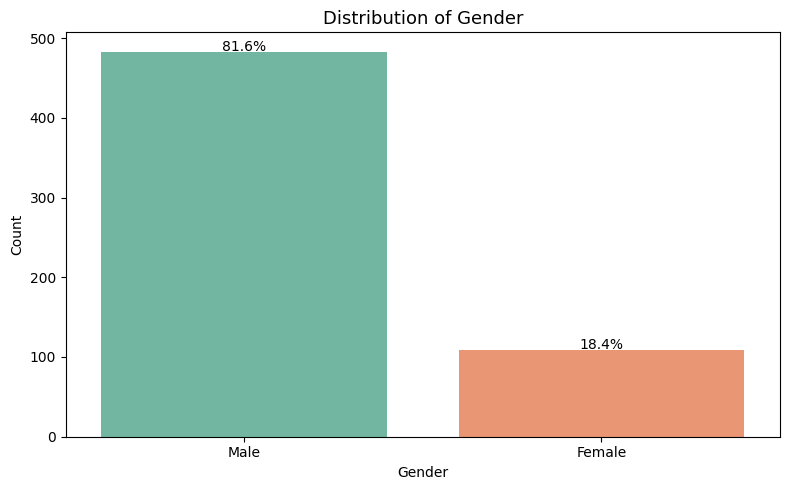

In [47]:
univariate_categorical_eda(df, "Gender")

Feature: Gender
        Count  Percentage
Gender                   
Male      483       81.59
Female    109       18.41



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


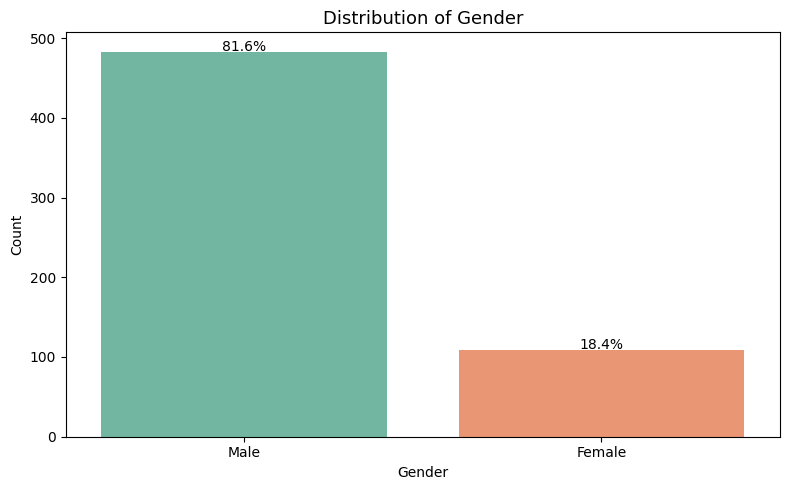

Feature: Married
         Count  Percentage
Married                   
Yes        386        65.2
No         206        34.8



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


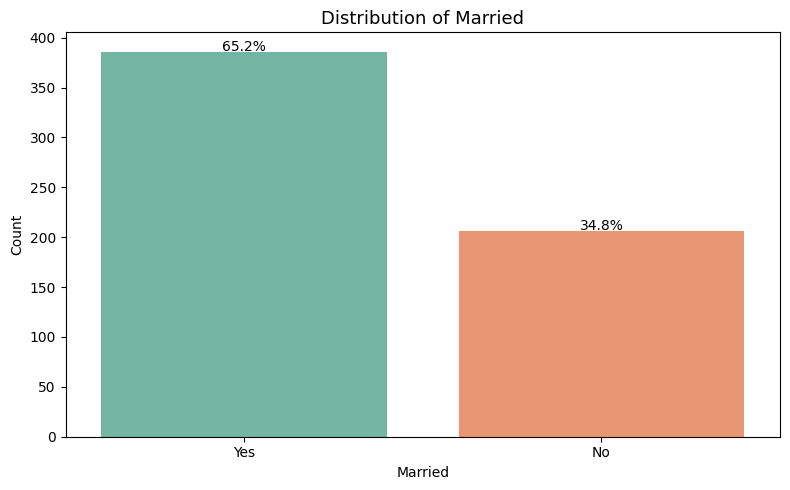

Feature: Dependents
            Count  Percentage
Dependents                   
0             347       58.61
1              98       16.55
2              98       16.55
4              49        8.28



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


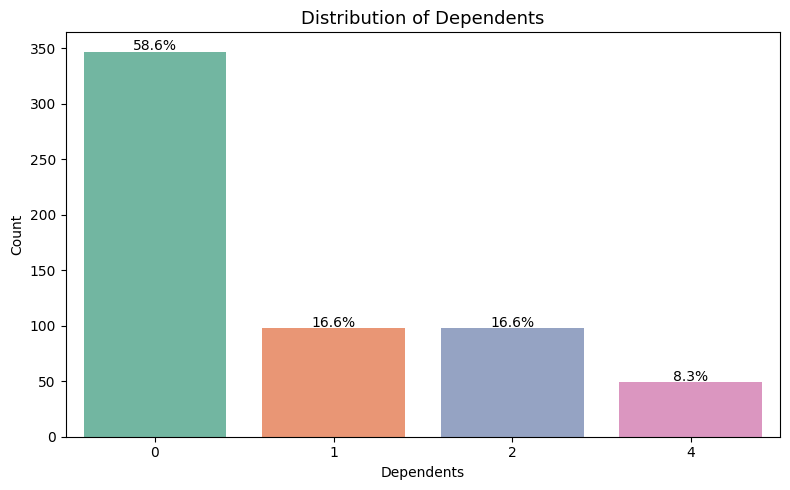

Feature: Education
              Count  Percentage
Education                      
Graduate        465       78.55
Not Graduate    127       21.45



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


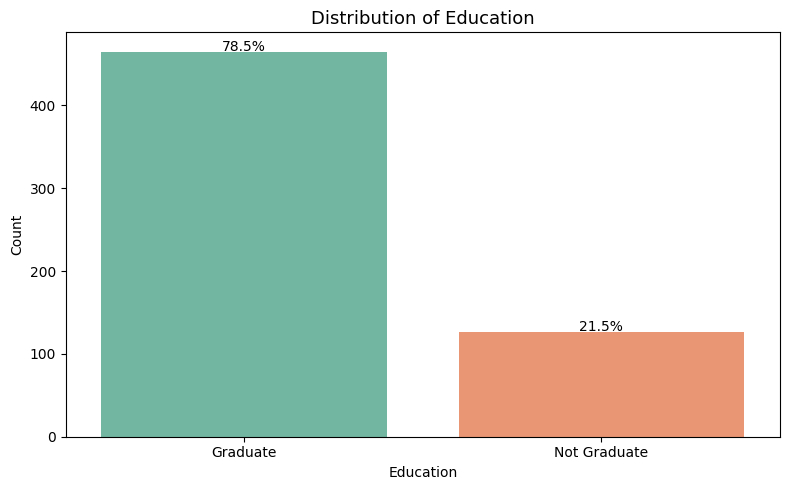

Feature: Self_Employed
               Count  Percentage
Self_Employed                   
No               513       86.66
Yes               79       13.34



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


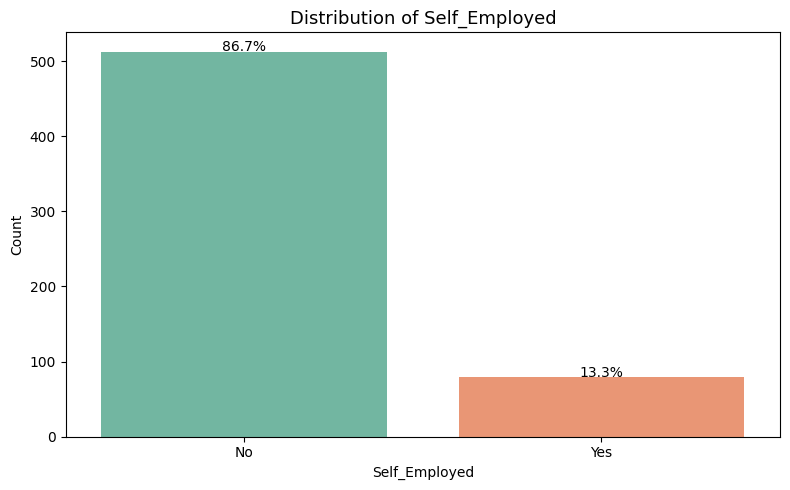

Feature: Property_Area
               Count  Percentage
Property_Area                   
Semiurban        228       38.51
Urban            191       32.26
Rural            173       29.22



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


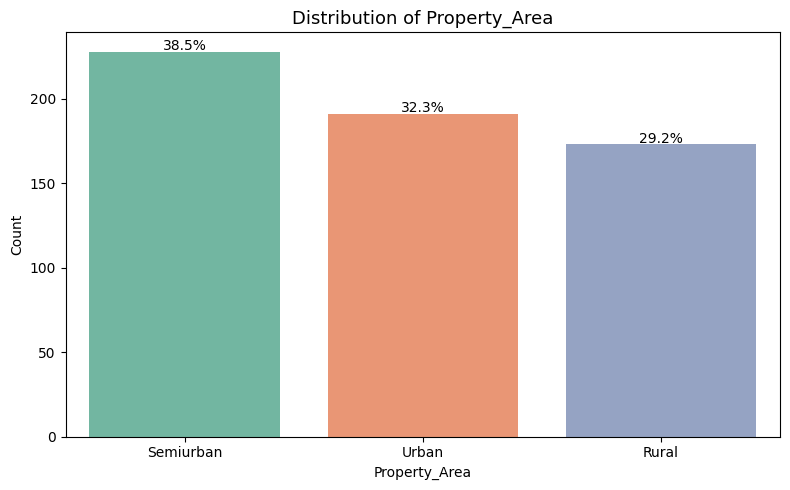

Feature: Loan_Status
             Count  Percentage
Loan_Status                   
Y              411       69.43
N              181       30.57



C:\Users\Osisami\AppData\Local\Temp\ipykernel_13496\3762713879.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


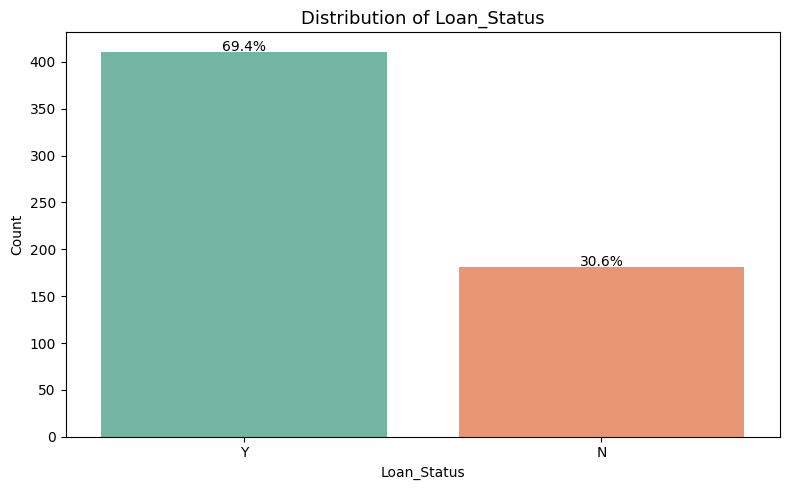

In [48]:
for column in categorical_features:
    univariate_categorical_eda(df, column)

BIVARIATE ANALYSIS

In [50]:
df["Loan_Status"] = df["Loan_Status"].replace({"Y": 1, "N": 0})
df["Loan_Status"]

Loan_ID
LP001003    0
LP001005    1
LP001006    1
LP001008    1
LP001011    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    0
Name: Loan_Status, Length: 592, dtype: int64

In [51]:
df["Loan_Status"].dtype

dtype('int64')

In [55]:
def correlation_with_target(df, target_col):
    """ 
    Plots a heatmap showing correlation of each numeric feature against target_col.
    Returns a Series of correlations (sorted by absolute magnitude). 
    """
    
    # Call only numeric columns and check if the target exists therein
    numerical_df = df.select_dtypes(include='number').copy()
    
    if target_col not in numerical_df.columns:
        raise ValueError(f"Target column '{target_col}' must be numerical and present in the dataframe.")
    
    # compute correlations of every numeric column with the target
    corrs = numerical_df.corrwith(numerical_df[target_col]).drop(target_col)
    
    corrs_df = corrs.to_frame(name='corr').T
    
    plt.figure(figsize=(10,2))
    sns.heatmap(
        corrs_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={"orientation": "vertical", "shrink":0.7}
    )
    plt.xticks(rotation=30, ha='right')
    plt.yticks([0], [target_col], rotation=0)
    plt.title(f"Correlation of numerical features with {target_col}", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # return sorted correlations for downstream use
    return corrs.reindex(corrs.abs().sort_values(ascending=False).index) 

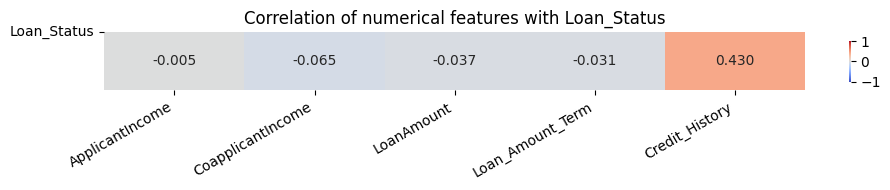

Credit_History       0.429578
CoapplicantIncome   -0.065034
LoanAmount          -0.037318
Loan_Amount_Term    -0.031256
ApplicantIncome     -0.004514
dtype: float64


In [56]:
corr_series = correlation_with_target(df, "Loan_Status")
print(corr_series)


In [57]:
from scipy.stats import pearsonr

def numeric_bivariate_plot(df, x_col, y_col):
    """ 
    Plots the relationship between two numeric variables with a regression line 
    and displays the correlation coefficient.
    
    Parameters:
    -----------
    data : pandas.DataFrame
         Dataset containing  the numeric columns
    x_col : str
        Name of the first numeric variable (x-axis)
    y_col : str
        Name of the second numeric variable (y-axis)
    """
    
    # Calculate correlation coefficient
    corr, p_value = pearsonr(df[x_col], df[y_col])
    
    # Create plot
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=x_col, y=y_col, scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
    
    # Title and labels
    plt.title(f"{y_col} vs {x_col}\nCorrelation: {corr:.3f} (p={p_value:.3f})", fontsize=13)
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel(y_col, fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

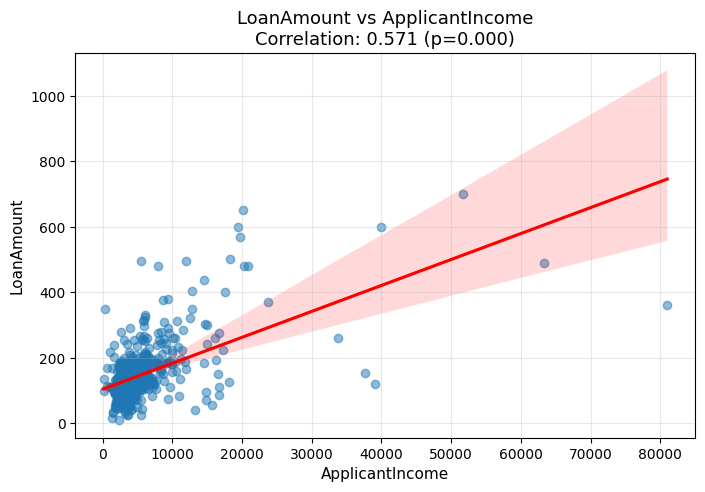

In [59]:
numeric_bivariate_plot(df, "ApplicantIncome", "LoanAmount")

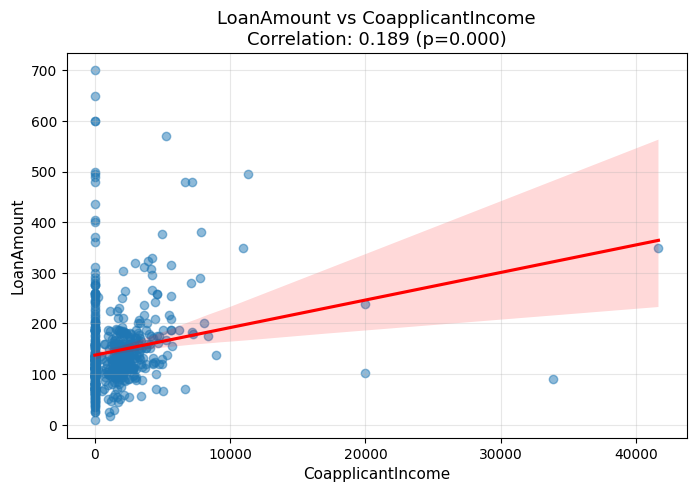

In [60]:
numeric_bivariate_plot(df, "CoapplicantIncome", "LoanAmount")

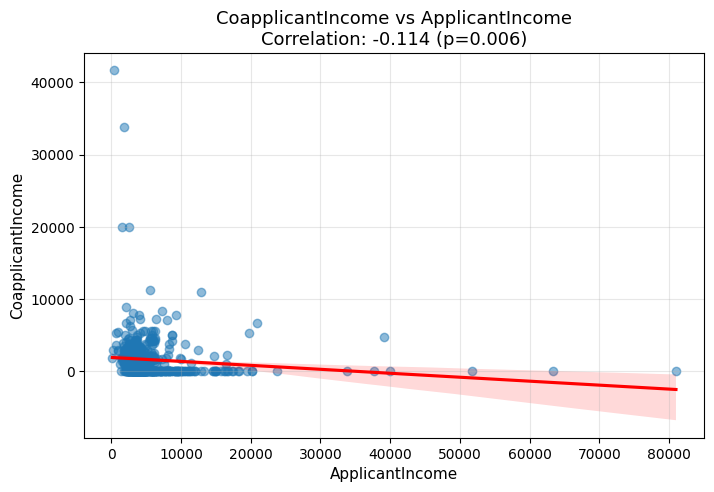

In [61]:

numeric_bivariate_plot(df, 'ApplicantIncome', 'CoapplicantIncome')

TRIVARIATE ANALYSIS

In [62]:
# To perform this, I need to define the function by comparing two features against the target variable

def trivariate_plot(df, x_col, y_col, hue_col):
    """
    Visualizes the relationship between two numeric variables (x_col, y_col)
    with a third target variable (loan approval status) shown by color (hue)
    
    Parameters
    ----------
    data : pandas.DataFrame
        The dataset.
    x_col : str
        The first numeric feature (x-axis).
    y_col : str
        The second numeric feature (y-axis).
    hue_col : str
        The target feature (color grouping).
    """
    
    plt.figure(figsize=(8, 6))
    sns.lmplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        height=6,
        aspect=1.2,
        scatter_kws={'alpha':0.6},
        line_kws={'linewidth':2}
    )
    plt.title(f"{y_col} vs {x_col} by {hue_col}", fontsize=13)
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel(y_col, fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

<Figure size 800x600 with 0 Axes>

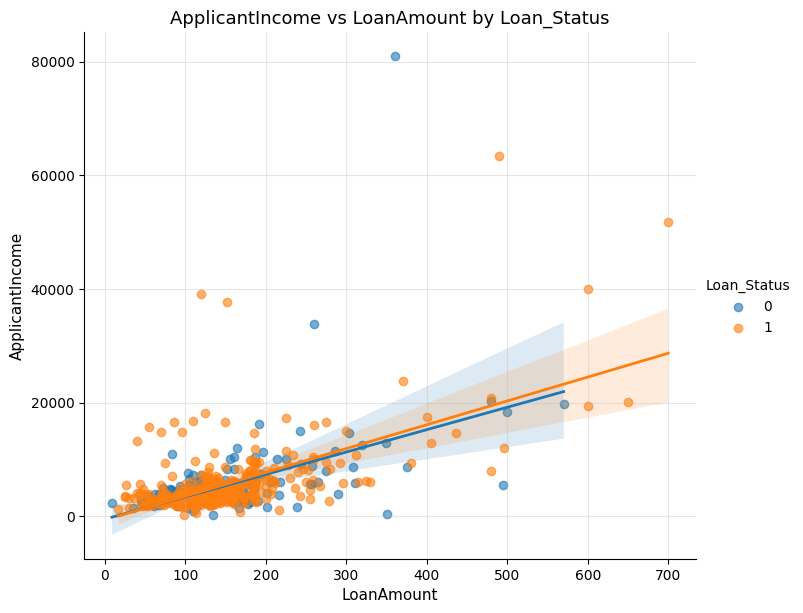

In [63]:
trivariate_plot(df, "LoanAmount", "ApplicantIncome", "Loan_Status")

# BASELINE MODEL